In [13]:
# Ensure python (*.py) files are reloaded correctly while editing them
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from huggingface_hub import notebook_login, HfApi

api = HfApi()
try:
    who = api.whoami()
    print("logged in as:", who['name'])
except Exception:
    print("not logged in")
    notebook_login()

logged in as: KostyalBalint


In [ ]:
from utils.DINOv3Wrapper import DINOv3Wrapper
from utils.mvtechDataset import ensure_mvtech_dataset_is_downloaded, get_categories, load_mvtec_data

dataset_path = ensure_mvtech_dataset_is_downloaded(".")
categories = get_categories(dataset_path)
print(categories)
category = "hazelnut"
num_shots = 8

reference_images, test_images, test_labels, test_masks = load_mvtec_data(
    dataset_path, category, num_shots
)

model = DINOv3Wrapper(
    model_name="facebook/dinov3-vits16-pretrain-lvd1689m",
    smaller_edge_size=32*20
)

Dataset already exists at ./mvtec_anomaly_detection
['transistor', 'wood', 'capsule', 'metal_nut', 'pill', 'zipper', 'tile', 'hazelnut', 'carpet', 'cable', 'leather', 'screw', 'toothbrush', 'bottle', 'grid']
Loaded 8 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
Loading facebook/dinov3-vits16-pretrain-lvd1689m on cpu...
Model loaded! Hidden dim: 384, Register tokens: 4, Patch size: 16
Smaller edge size: 1024


In [ ]:
from utils.build_memory_bank import build_memory_bank

# Build memory bank with rotation augmentation
nn_index, features_ref, num_features = build_memory_bank(
    model=model,
    reference_images=reference_images,
    use_rotation=False,
    normalize_features=True
)

print(f"\nMemory bank ready with {num_features} patches!")

Building memory bank from 8 images...
Rotation augmentation: False


Processing reference images:   0%|          | 0/8 [00:00<?, ?it/s]

Total patches in memory bank: 32768
Memory bank built! Index size: 32768

Memory bank ready with 32768 patches!


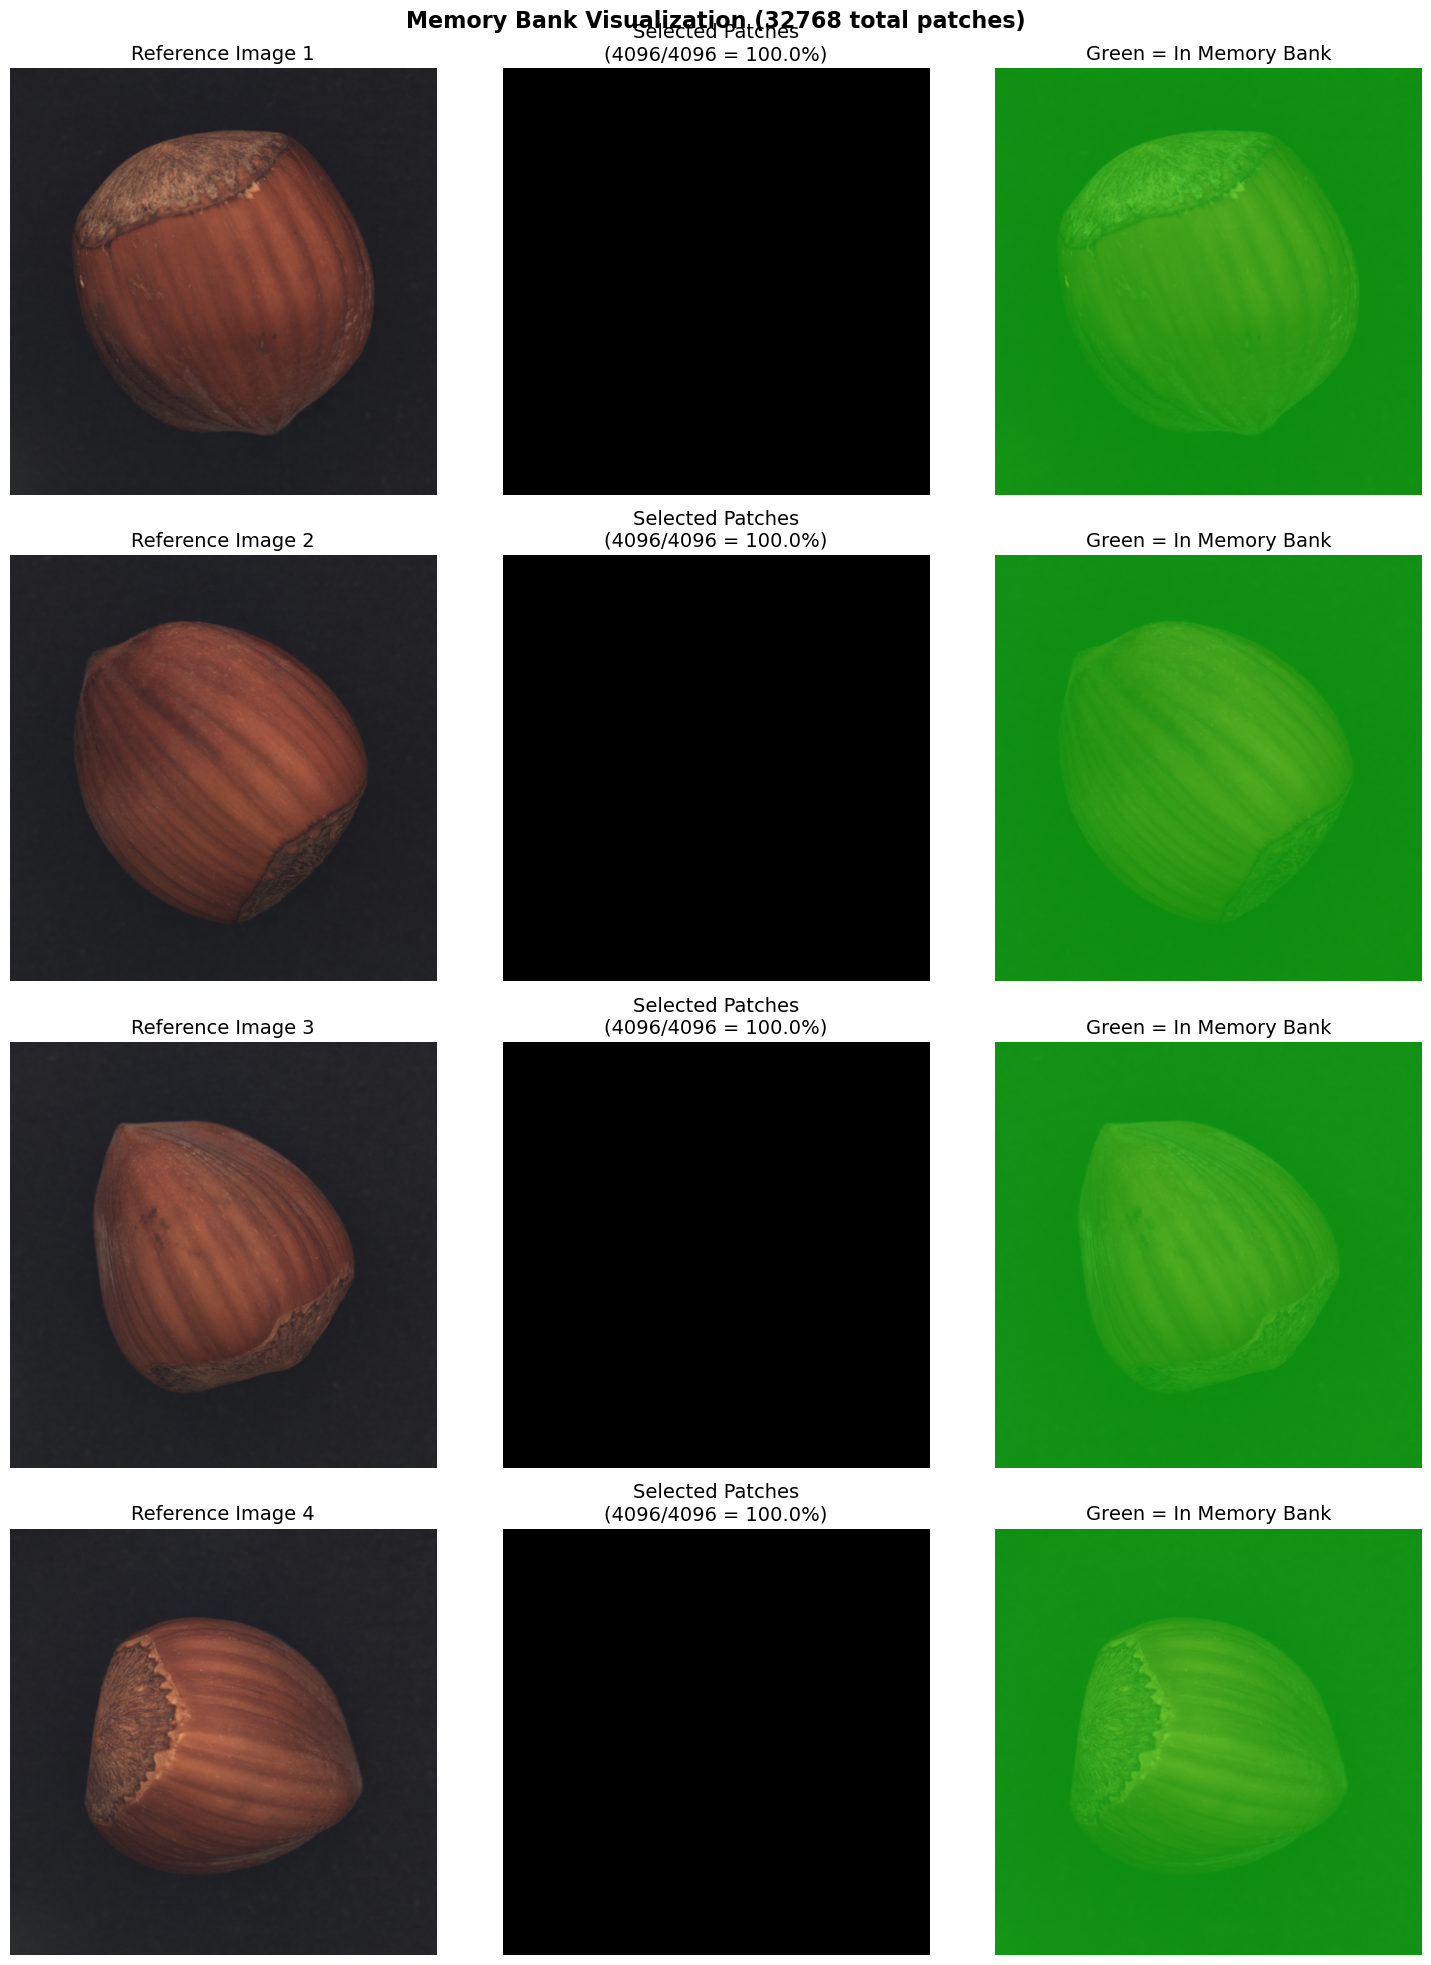


Memory Bank Statistics:
Reference images: 8
Rotation augmentation: No
PCA masking: Yes
Total patches in memory: 32768
Feature dimension: 384
Patches per image (avg): 4096.0
Memory bank size: 48.00 MB


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Visualize what patches are in the memory bank
num_display = min(4, len(reference_images))  # Show up to 4 reference images

fig, axes = plt.subplots(num_display, 3, figsize=(15, 5*num_display))
if num_display == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_display):
    ref_img = reference_images[idx]

    # Extract features and mask
    img_tensor, grid_size = model.prepare_image(ref_img)
    features = model.extract_features(img_tensor)
    mask = model.compute_background_mask(features, grid_size,
                                        smoothing_sigma=4)

    # Original image
    axes[idx, 0].imshow(ref_img)
    axes[idx, 0].set_title(f'Reference Image {idx+1}', fontsize=14)
    axes[idx, 0].axis('off')

    # Mask visualization
    mask_2d = mask.reshape(grid_size)
    axes[idx, 1].imshow(mask_2d, cmap='gray')
    axes[idx, 1].set_title(f'Selected Patches\n({mask.sum()}/{len(mask)} = {mask.sum()/len(mask)*100:.1f}%)', fontsize=14)
    axes[idx, 1].axis('off')

    # Overlay on image
    mask_overlay = cv2.resize(mask_2d.astype(np.uint8) * 255,
                             (ref_img.shape[1], ref_img.shape[0]),
                             interpolation=cv2.INTER_NEAREST)
    overlay = ref_img.copy()
    overlay[mask_overlay > 0] = overlay[mask_overlay > 0] * 0.5 + np.array([0, 255, 0]) * 0.5
    axes[idx, 2].imshow(overlay.astype(np.uint8))
    axes[idx, 2].set_title('Green = In Memory Bank', fontsize=14)
    axes[idx, 2].axis('off')

plt.suptitle(f'Memory Bank Visualization ({num_features} total patches)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistics
print(f"\n{'='*60}")
print(f"Memory Bank Statistics:")
print(f"{'='*60}")
print(f"Reference images: {len(reference_images)}")
print(f"Rotation augmentation: {'Yes (8x)' if False else 'No'}")  # matches use_rotation
print(f"PCA masking: {'Yes' if True else 'No'}")  # matches use_masking
print(f"Total patches in memory: {num_features}")
print(f"Feature dimension: {features_ref.shape[1]}")
print(f"Patches per image (avg): {num_features / len(reference_images):.1f}")
print(f"Memory bank size: {features_ref.nbytes / (1024**2):.2f} MB")
print(f"{'='*60}")